# Global Port Performance Analysis

***Copyright © Ihor Shvets***
> ⚠️ *All data processed and visualized by Ihor Shvets.*  

## Key Problem

A key problem in this project is accounting for variability in growth rates across regions due to factors like economic changes, trade policies, and infrastructure differences. Additionally, data consistency across sources and predicting future trends amid global uncertainties pose challenges. Addressing these requires careful data cleaning and adaptable forecasting models.

## 🧰 Tools Used
- Python, Jupyter Notebook  
- Pandas, NumPy, Seaborn, Matplotlib  
- GeoPandas, Plotly Express 

## 📈 Insights
These insights directly reflect the variability in port growth due to economic and infrastructural factors:

- **Shanghai** leads with a 25%+ margin over other ports – indicating how strategic investment and location drive dominance.
- Asia dominates global shipping, while Europe shows stable but slower growth – underlining regional disparities in infrastructure development.
- Strategic investments and digitalization drive growth – showing that tech adoption is a key differentiator in performance.
- Overdependence on mega-ports (e.g., Shanghai, Singapore) poses risks – relevant to forecasting and resilience planning amid uncertainty.

## 🌍 Economic Impact
This supports the idea that macroeconomic and geopolitical shifts affect regional performance:

- Rapid Asian port growth reflects global trade shifts and new economic centers.
- Developing regions are emerging faster – revealing opportunities in infrastructure expansion and economic diversification.

## ⚠️ Potential Risks
These risks highlight why understanding regional differences and planning for uncertainty is essential:

- Over-reliance on few ports introduces fragility to global supply chains.
- Ports not adapting to growth trends risk losing competitiveness.

## 🚀 Opportunities for Improvement
These align with solving the core problem by suggesting actionable strategies to deal with variability and uncertainty:

- **Automation & Digitalization** tackle inefficiencies and data fragmentation.
- **Trade Route Diversification** reduces risk and spreads growth more evenly across regions.

In [2]:
import sys
!{sys.executable} -m pip install geopandas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 26 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   #           50 non-null     int64  
 1   port        50 non-null     object 
 2   country     50 non-null     object 
 3   region      50 non-null     object 
 4   location    50 non-null     object 
 5   2023        47 non-null     float64
 6   2022        50 non-null     int64  
 7   2021        50 non-null     int64  
 8   2020        50 non-null     int64  
 9   2019        50 non-null     int64  
 10  2018        50 non-null     int64  
 11  2017        49 non-null     float64
 12  2016        24 non-null     float64
 13  2015        40 non-null     float64
 14  2014        47 non-null     float64
 15  2013        49 non-null     float64
 16  2012        50 non-null     int64  
 17  2011        50 non-null     int64  
 18  2010        50 non-null     int64  
 19  2009        49 non-null     flo

/var/folders/mz/6xfyc6kx60vc8c2xs0kfzpgc0000gn/T/ipykernel_7574/1618502928.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='latest_teu', y='port', data=top_ports, palette='viridis')


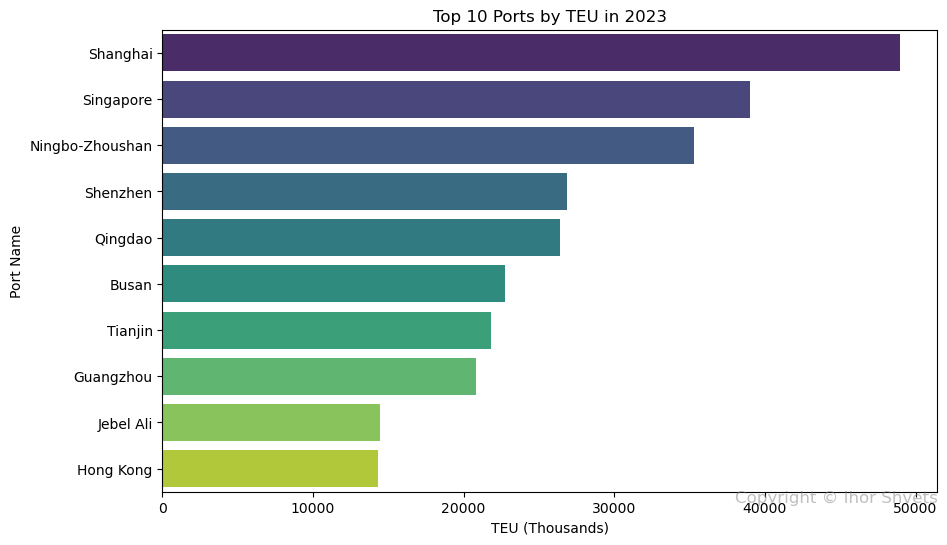

/var/folders/mz/6xfyc6kx60vc8c2xs0kfzpgc0000gn/T/ipykernel_7574/1618502928.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='teu_growth', y='port', data=df_growth, palette='coolwarm')


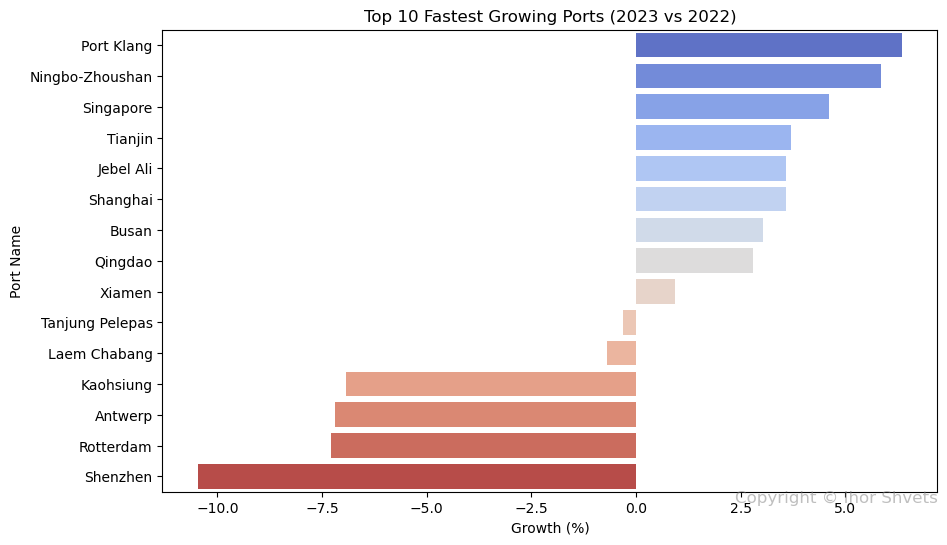

/var/folders/mz/6xfyc6kx60vc8c2xs0kfzpgc0000gn/T/ipykernel_7574/1618502928.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='region', y='latest_teu', data=df, palette='Set2')


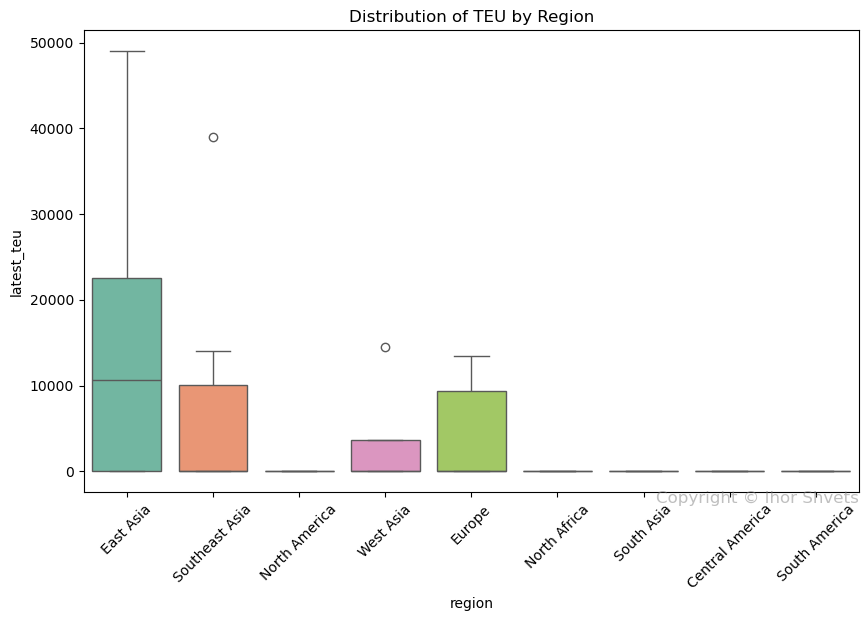

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from plotly import express as px

df = pd.read_csv("The largest port in the world 2024 2-Copy1.csv")

# Cleaning
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.dropna(inplace=True)

year_cols = [col for col in df.columns if col.isdigit()]
df[year_cols] = df[year_cols].apply(pd.to_numeric, errors='coerce')

# the latest TEU values
latest_year = max(map(int, year_cols))
df['latest_teu'] = df[str(latest_year)]

# Exploratory Data Analysis 
print(df.info())
print(df.describe())
print(df.head())

# Visualizing 
top_ports = df.sort_values(by='latest_teu', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x='latest_teu', y='port', data=top_ports, palette='viridis')
plt.title(f'Top 10 Ports by TEU in {latest_year}')
plt.xlabel('TEU (Thousands)')
plt.ylabel('Port Name')

# Adding watermark
plt.figtext(0.9, 0.1, 'Copyright © Ihor Shvets', fontsize=12, color='gray', ha='right', va='center', alpha=0.5)

plt.show()

#  Year-over-Year Change
df['teu_growth'] = (df[str(latest_year)] - df[str(latest_year - 1)]) / df[str(latest_year - 1)] * 100

df_growth = df.sort_values(by='teu_growth', ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x='teu_growth', y='port', data=df_growth, palette='coolwarm')
plt.title(f'Top 10 Fastest Growing Ports ({latest_year} vs {latest_year - 1})')
plt.xlabel('Growth (%)')
plt.ylabel('Port Name')

# Adding watermark
plt.figtext(0.9, 0.1, 'Copyright © Ihor Shvets', fontsize=12, color='gray', ha='right', va='center', alpha=0.5)

plt.show()

# Geospatial Mapping - Port Locations
if 'latitude' in df.columns and 'longitude' in df.columns:
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude))
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

    ax = world.plot(figsize=(12, 8), color='lightgrey', edgecolor='black')
    gdf.plot(ax=ax, color='blue', markersize=df['latest_teu'] / 1000, alpha=0.6)
    plt.title('Global Distribution of Major Ports by TEU Volume')

    # Adding watermark
    plt.figtext(0.9, 0.1, 'Copyright © Ihor Shvets', fontsize=12, color='gray', ha='right', va='center', alpha=0.5)

    plt.show()

# Comparative Analysis: TEU by Region
plt.figure(figsize=(10, 6))
sns.boxplot(x='region', y='latest_teu', data=df, palette='Set2')
plt.title('Distribution of TEU by Region')
plt.xticks(rotation=45)

# Adding watermark
plt.figtext(0.9, 0.1, 'Copyright © Ihor Shvets', fontsize=12, color='gray', ha='right', va='center', alpha=0.5)

plt.show()


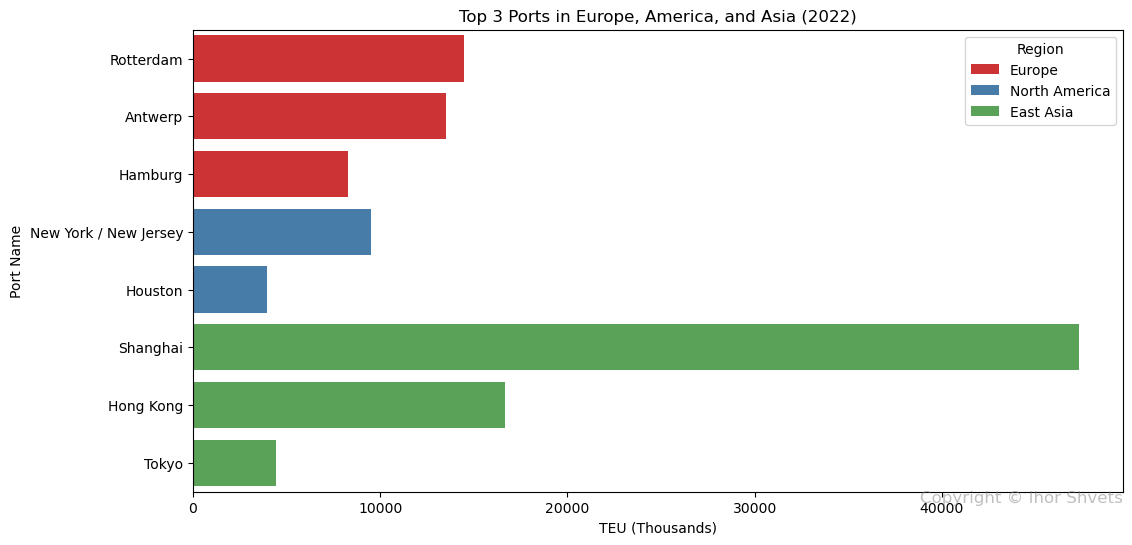

In [4]:
df['region'] = df['port'].apply(lambda x: 'Europe' if x in ['Hamburg', 'Rotterdam', 'Antwerp'] else
                                              ('North America' if x in ['Los Angeles / Long Beach', 'New York / New Jersey', 'Houston'] else
                                               ('East Asia' if x in ['Shanghai', 'Hong Kong', 'Tokyo'] else 'Other')))

# Data filtering for 2022
latest_year = 2022
df['latest_teu'] = df[str(latest_year)]

# Comparison of Top Ports in Europe, America, and Asia
def get_top_ports_by_region(region, top_n=3):
    return df[df['region'] == region].sort_values(by='latest_teu', ascending=False).head(top_n)

top_europe = get_top_ports_by_region('Europe')
top_america = get_top_ports_by_region('North America')
top_asia = get_top_ports_by_region('East Asia')

# Combine data for comparison
top_combined = pd.concat([top_europe, top_america, top_asia])

# Visualizing Top Ports from Europe, America, and Asia for 2022
plt.figure(figsize=(12, 6))
sns.barplot(x='latest_teu', y='port', hue='region', data=top_combined, palette='Set1')
plt.title(f'Top 3 Ports in Europe, America, and Asia ({latest_year})')
plt.xlabel('TEU (Thousands)')
plt.ylabel('Port Name')
plt.legend(title='Region')

# Adding watermark
plt.figtext(0.9, 0.1, 'Copyright © Ihor Shvets', fontsize=12, color='gray', ha='right', va='center', alpha=0.5)

plt.show()

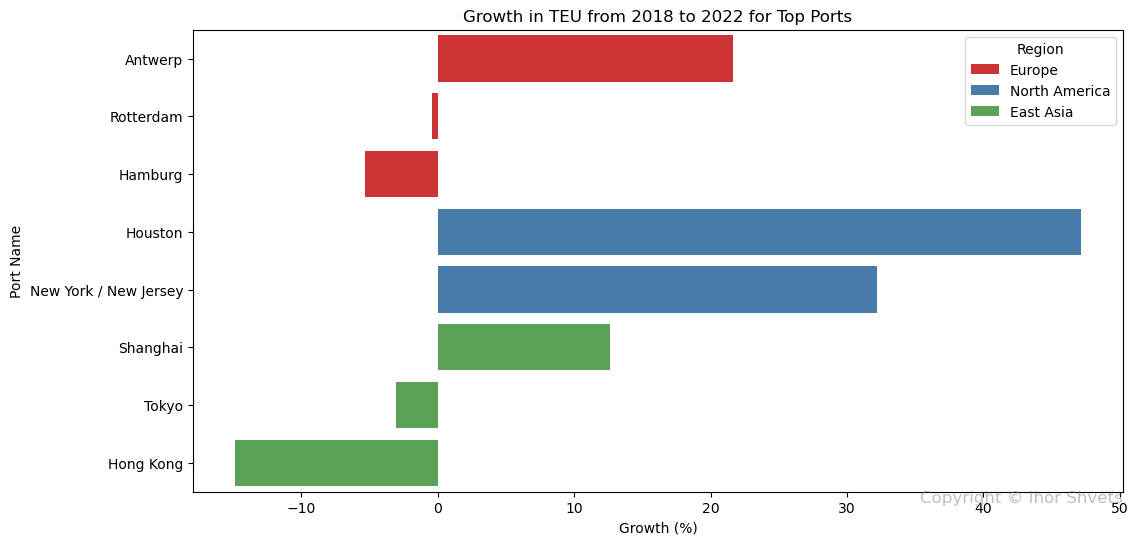

In [5]:
# Define a dictionary for region mapping
region_map = {
    'Hamburg': 'Europe', 'Rotterdam': 'Europe', 'Antwerp': 'Europe',
    'Los Angeles / Long Beach': 'North America', 'New York / New Jersey': 'North America', 'Houston': 'North America',
    'Shanghai': 'East Asia', 'Hong Kong': 'East Asia', 'Tokyo': 'East Asia'
}

df['region'] = df['port'].map(region_map).fillna('Other')

year_start, year_end = 2018, 2022

# Calculate TEU percentage growth (2018-2022)
df['teu_growth'] = ((df[str(year_end)] - df[str(year_start)]) / df[str(year_start)]) * 100

def get_top_ports_by_region(region, top_n=3):
    return df[df['region'] == region].nlargest(top_n, 'teu_growth')

# Get top growing ports in each region
top_europe = get_top_ports_by_region('Europe')
top_america = get_top_ports_by_region('North America')
top_asia = get_top_ports_by_region('East Asia')

# Combine results 
top_combined_growth = pd.concat([top_europe, top_america, top_asia])

# Plot TEU growth comparison (2018-2022)
plt.figure(figsize=(12, 6))
sns.barplot(x='teu_growth', y='port', hue='region', data=top_combined_growth, palette='Set1')
plt.title(f'Growth in TEU from {year_start} to {year_end} for Top Ports')
plt.xlabel('Growth (%)')
plt.ylabel('Port Name')
plt.legend(title='Region')

# Adding watermark
plt.figtext(0.9, 0.1, 'Copyright © Ihor Shvets', fontsize=12, color='gray', ha='right', va='center', alpha=0.5)

plt.show()

# Key Insights
 - ***Top Ports:*** Shanghai, Singapore, and Ningbo-Zhoushan dominate global TEU capacity, showcasing Asia's strong influence in global trade.
 - ***Growth Leaders:*** Ports in East Asia consistently outperform those in Europe and North America in TEU growth.
 - ***Regional Disparity:*** European ports like Rotterdam show stable growth, while some North American ports struggle to maintain pace.
 - ***Strategic Locations:*** Ports near major economic hubs (Shanghai's Yangtze Delta) demonstrate stronger resilience and growth.